In [3]:
%reload_ext autoreload
%autoreload 2
import mujoco
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller
from submission.config import load_config

config = load_config("submission/config/vision_config.yaml")
sim = MiniprojectSimulation(level=2, seed=67)
controller = Controller(sim, config)
#controller.wind.process_wind = _cheat_process_wind

thorax_id = mujoco.mj_name2id(sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, f"{sim.fly.name}/c_thorax")

wind_signal = []
wind_direction = []
wind_direction_estimated = []
fly_thorax_quat = []
qpos_history = []

for _ in trange(50000): #10000
    joint_angles, adhesion = controller.step(sim)
    wind_signal.append(controller.wind.current_signal)
    wind_direction.append(sim.mj_model.opt.wind[:2].copy())
    wind_direction_estimated.append(controller.wind.estimated_wind_angles[-1])
    fly_thorax_quat.append(sim.mj_data.xquat[thorax_id].copy())  # [w, x, y, z]
    antenna_data = sim.get_antenna_data(sim.fly.name)
    qpos_history.append({
        'q_lx': antenna_data['l']['qpos'][1], 
        'q_ly': antenna_data['l']['qpos'][2], 
        'q_lz': antenna_data['l']['qpos'][3],
        'q_rx': antenna_data['r']['qpos'][1], 
        'q_ry': antenna_data['r']['qpos'][2], 
        'q_rz': antenna_data['r']['qpos'][3],
        'qacc_lx': antenna_data['l']['qacc'][0], 
        'qacc_ly': antenna_data['l']['qacc'][1], 
        'qacc_lz': antenna_data['l']['qacc'][2],
        'qacc_rx': antenna_data['r']['qacc'][0], 
        'qacc_ry': antenna_data['r']['qacc'][1],
        'qacc_rz': antenna_data['r']['qacc'][2],
        'qvel_lx': antenna_data['l']['qvel'][0], 
        'qvel_ly': antenna_data['l']['qvel'][1], 
        'qvel_lz': antenna_data['l']['qvel'][2],
        'qvel_rx': antenna_data['r']['qvel'][0], 
        'qvel_ry': antenna_data['r']['qvel'][1],
        'qvel_rz': antenna_data['r']['qvel'][2],
    })
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()

 10%|▉         | 4830/50000 [00:26<04:09, 180.82it/s]


KeyboardInterrupt: 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


wind_signal = np.asarray(wind_signal)
wind_direction = np.asarray(wind_direction)        # shape (T, 2): [wind_x, wind_y] in world frame  # shape (T,): estimated wind angle in fly's egocentric frame
wind_direction_estimated_degrees = np.degrees(wind_direction_estimated)  # convert to degrees for easier interpretation
fly_thorax_quat = np.asarray(fly_thorax_quat)      # shape (T, 4): [w, x, y, z]
qpos_df = df = pd.DataFrame(qpos_history)  # shape (T, 4): q_lx, q_ly, q_rx, q_ry

x = np.arange(len(wind_signal))

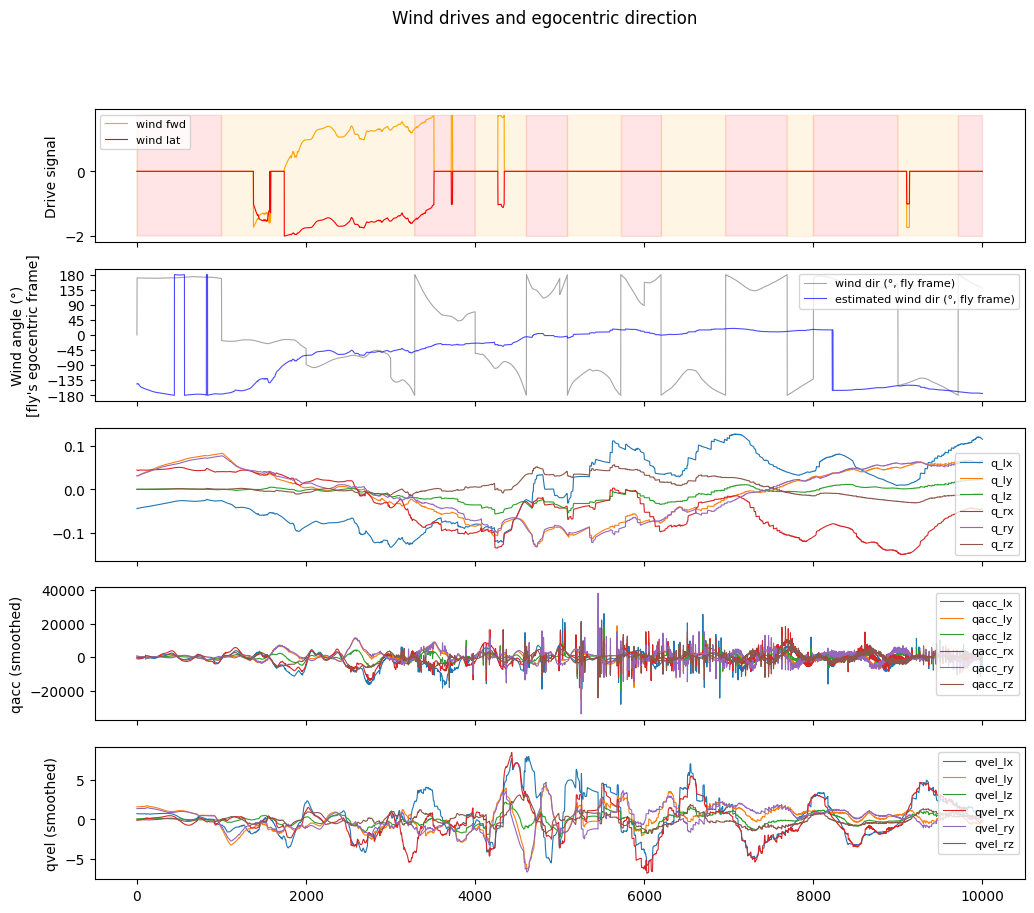

In [ ]:
from matplotlib.gridspec import GridSpec

# World-frame wind angle and magnitude from MuJoCo opt.wind
wind_angle_world = np.arctan2(wind_direction[:, 1], wind_direction[:, 0])
wind_magnitude   = np.linalg.norm(wind_direction, axis=1)

# Fly heading (yaw) extracted from thorax quaternion [w, x, y, z]
w, x_, y_, z_ = fly_thorax_quat[:, 0], fly_thorax_quat[:, 1], fly_thorax_quat[:, 2], fly_thorax_quat[:, 3]
fly_yaw = np.arctan2(2 * (w * z_ + x_ * y_), 1 - 2 * (y_**2 + z_**2))

# Wind angle in fly's egocentric frame (wrapped to [-180, 180])
egocentric_wind_angle = np.degrees(np.arctan2(
    np.sin(wind_angle_world - fly_yaw),
    np.cos(wind_angle_world - fly_yaw),
))



fig, (ax1, ax1b, ax2, ax2b, ax2c) = plt.subplots(5, 1, figsize=(12, 10), sharex=True)


ax1.plot(x, wind_signal[:, 0], label='wind fwd',  lw=0.8, color='orange')
ax1.plot(x, wind_signal[:, 1], label='wind lat', lw=0.8, color='red')
ax1.set_ylabel('Drive signal')
ax1.legend(loc='upper left', fontsize=8)
ax1.tick_params(labelbottom=False)

ax1.fill_between(x, np.min(wind_signal), np.max(wind_signal), where=egocentric_wind_angle < 0,  alpha=0.1, color='orange')
ax1.fill_between(x, np.min(wind_signal), np.max(wind_signal), where=egocentric_wind_angle >= 0, alpha=0.1, color='red')

ax2.plot(x, qpos_df[['q_lx', 'q_ly', 'q_lz', 'q_rx', 'q_ry', 'q_rz']], lw=0.8)
ax2.legend(qpos_df.columns, fontsize=8)

ax1b.plot(x, egocentric_wind_angle, color='gray', alpha=0.7, lw=0.8, label='wind dir (°, fly frame)')
ax1b.plot(x, wind_direction_estimated_degrees, color='blue', alpha=0.7, lw=0.8, label='estimated wind dir (°, fly frame)')
ax1b.set_ylabel("Wind angle (°)\n[fly's egocentric frame]")
ax1b.set_yticks([-180, -135, -90, -45, 0, 45, 90, 135, 180])
#ax1b.set_yticks([-180, -90, 0, 90, 180])
ax1b.legend(loc='upper right', fontsize=8)

smooth_window = 200

qacc_smooth = qpos_df[['qacc_lx', 'qacc_ly', 'qacc_lz', 'qacc_rx', 'qacc_ry', 'qacc_rz']].rolling(
    window=smooth_window, center=True, min_periods=1
).mean()

qvel_smooth = qpos_df[['qvel_lx', 'qvel_ly', 'qvel_lz', 'qvel_rx', 'qvel_ry', 'qvel_rz']].rolling(
    window=smooth_window, center=True, min_periods=1
).mean()

ax2b.plot(x, qacc_smooth, lw=0.8)
ax2b.legend(qacc_smooth.columns, fontsize=8)
ax2b.set_ylabel('qacc (smoothed)')

ax2c.plot(x, qvel_smooth, lw=0.8)
ax2c.legend(qvel_smooth.columns, fontsize=8)
ax2c.set_ylabel('qvel (smoothed)')

fig.suptitle('Wind drives and egocentric direction')
plt.show()

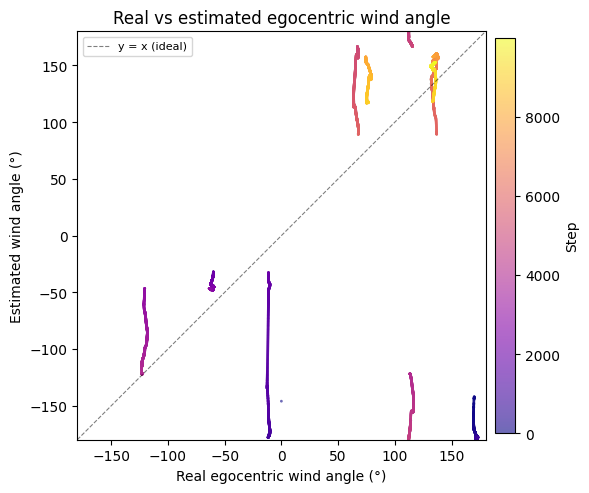

In [7]:
# Angle–angle scatter: real vs estimated egocentric wind angle, coloured by step
steps = np.arange(len(egocentric_wind_angle))

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

sc = ax.scatter(
    egocentric_wind_angle,
    wind_direction_estimated_degrees,
    c=steps, cmap='plasma', s=4, alpha=0.6, linewidths=0,
)

# ideal y = x line
lim = (-180, 180)
ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.5, label='y = x (ideal)')

ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_xlabel('Real egocentric wind angle (°)')
ax.set_ylabel('Estimated wind angle (°)')
ax.set_aspect('equal')
ax.legend(fontsize=8)

cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Step')

ax.set_title('Real vs estimated egocentric wind angle')
plt.tight_layout()
plt.show()


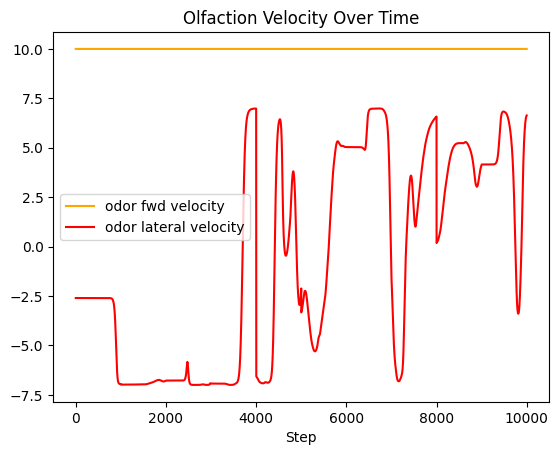

In [10]:
olfactory_signal = np.asarray(controller.olfaction.velocity_hist)

plt.figure()
plt.plot(x, olfactory_signal[:, 0], color="orange", label="odor fwd velocity")
plt.plot(x, olfactory_signal[:, 1], color="red", label="odor lateral velocity")
plt.title("Olfaction Velocity Over Time")
plt.xlabel("Step")
plt.legend()
plt.show()

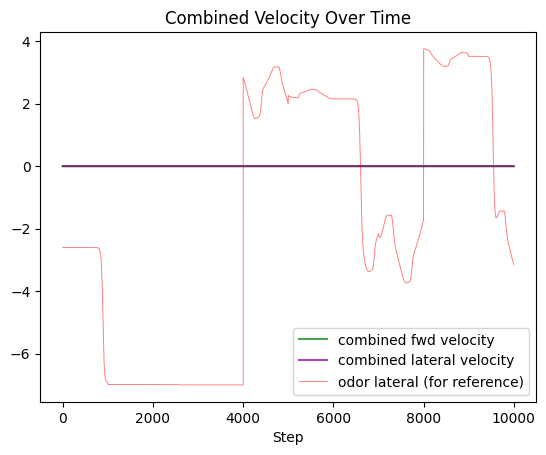

In [5]:
combined_velocity = np.asarray(controller.velocity_hist)
odor_vel = np.asarray(controller.olfaction.velocity_hist)

plt.figure()
plt.plot(x, combined_velocity[:, 0], color="green", label="combined fwd velocity", alpha=0.7)
plt.plot(x, combined_velocity[:, 1], color="purple", label="combined lateral velocity", alpha=0.7)
plt.plot(x, odor_vel[:, 1], color="red", label="odor lateral (for reference)", alpha=0.5, lw=0.7)
plt.title("Combined Velocity Over Time")
plt.xlabel("Step")
plt.legend()
plt.show()

In [8]:
import cv2
import mediapy

wind_dir_arr = np.asarray(wind_direction)          # (n_steps, 2) world-frame XY
fly_quat_arr = np.asarray(fly_thorax_quat)         # (n_steps, 4) [w,x,y,z]

# Yaw from thorax quaternion
w_, x_, y_, z_ = fly_quat_arr[:,0], fly_quat_arr[:,1], fly_quat_arr[:,2], fly_quat_arr[:,3]
fly_yaw_arr = np.arctan2(2*(w_*z_ + x_*y_), 1 - 2*(y_**2 + z_**2))

cam_name = list(sim.renderer.frames.keys())[0]
frames   = sim.renderer.frames[cam_name]
n_frames = len(frames)
n_steps  = len(wind_dir_arr)

# Evenly map frames -> simulation steps
frame_step_idx = np.round(np.linspace(0, n_steps - 1, n_frames)).astype(int)

h, w   = frames[0].shape[:2]
cx, cy = w - 55, h - 55   # compass centre (bottom-right corner)
R      = 32                # compass circle radius
AL     = 26                # arrow length in pixels

annotated = []
for i, frame in enumerate(frames):
    img  = frame.copy()
    step = frame_step_idx[i]

    # dark compass background
    cv2.circle(img, (cx, cy), R + 5, (20, 20, 20), -1)
    cv2.circle(img, (cx, cy), R + 5, (180, 180, 180), 1)

    # wind arrow (orange)
    wind = wind_dir_arr[step]
    norm = np.linalg.norm(wind)
    if norm > 1e-3:
        d  = wind / norm
        ex = int(cx + d[0] * AL)
        ey = int(cy - d[1] * AL)   # y flipped in image coords
        cv2.arrowedLine(img, (cx, cy), (ex, ey), (30, 140, 255), 2, tipLength=0.35)

    # fly heading arrow (green)
    yaw = fly_yaw_arr[step]
    hx  = int(cx + np.cos(yaw) * int(AL * 0.75))
    hy  = int(cy - np.sin(yaw) * int(AL * 0.75))
    cv2.arrowedLine(img, (cx, cy), (hx, hy), (60, 220, 60), 2, tipLength=0.35)

    # legend
    cv2.putText(img, 'W', (cx - 5, cy + R + 16),
                cv2.FONT_HERSHEY_SIMPLEX, 0.32, (30, 140, 255), 1)
    cv2.putText(img, 'H', (cx + 8, cy + R + 16),
                cv2.FONT_HERSHEY_SIMPLEX, 0.32, (60, 220, 60), 1)

    annotated.append(img)

mediapy.show_video(annotated, fps=25, title=f'{cam_name} — blue=wind  green=fly heading')

nmf/backcam — blue=wind green=fly heading This browser does not support the video tag.


In [ ]:
controller.olfaction.olfaction_smooth, sim.get_olfaction(sim.fly.name)

(array([[3.02365859e-08],
        [2.77959536e-08],
        [2.76207044e-08],
        [2.71062224e-08]]),
 array([[3.04457004e-08],
        [2.79823251e-08],
        [2.78146843e-08],
        [2.72956509e-08]]))

In [ ]:
sim.get_antenna_data(sim.fly.name).keys()

dict_keys(['l', 'r'])

In [ ]:
sim.get_antenna_data(sim.fly.name)['l'].keys()

dict_keys(['qpos', 'qvel', 'qacc', 'qfrc_passive'])

In [ ]:
sim.get_antenna_data(sim.fly.name)['l']['qvel']

array([-0.12694573, -0.09150428, -0.02246473])

/var/folders/7z/392mmwys43l8y6c7ym46p13w0000gn/T/ipykernel_84171/3212495622.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


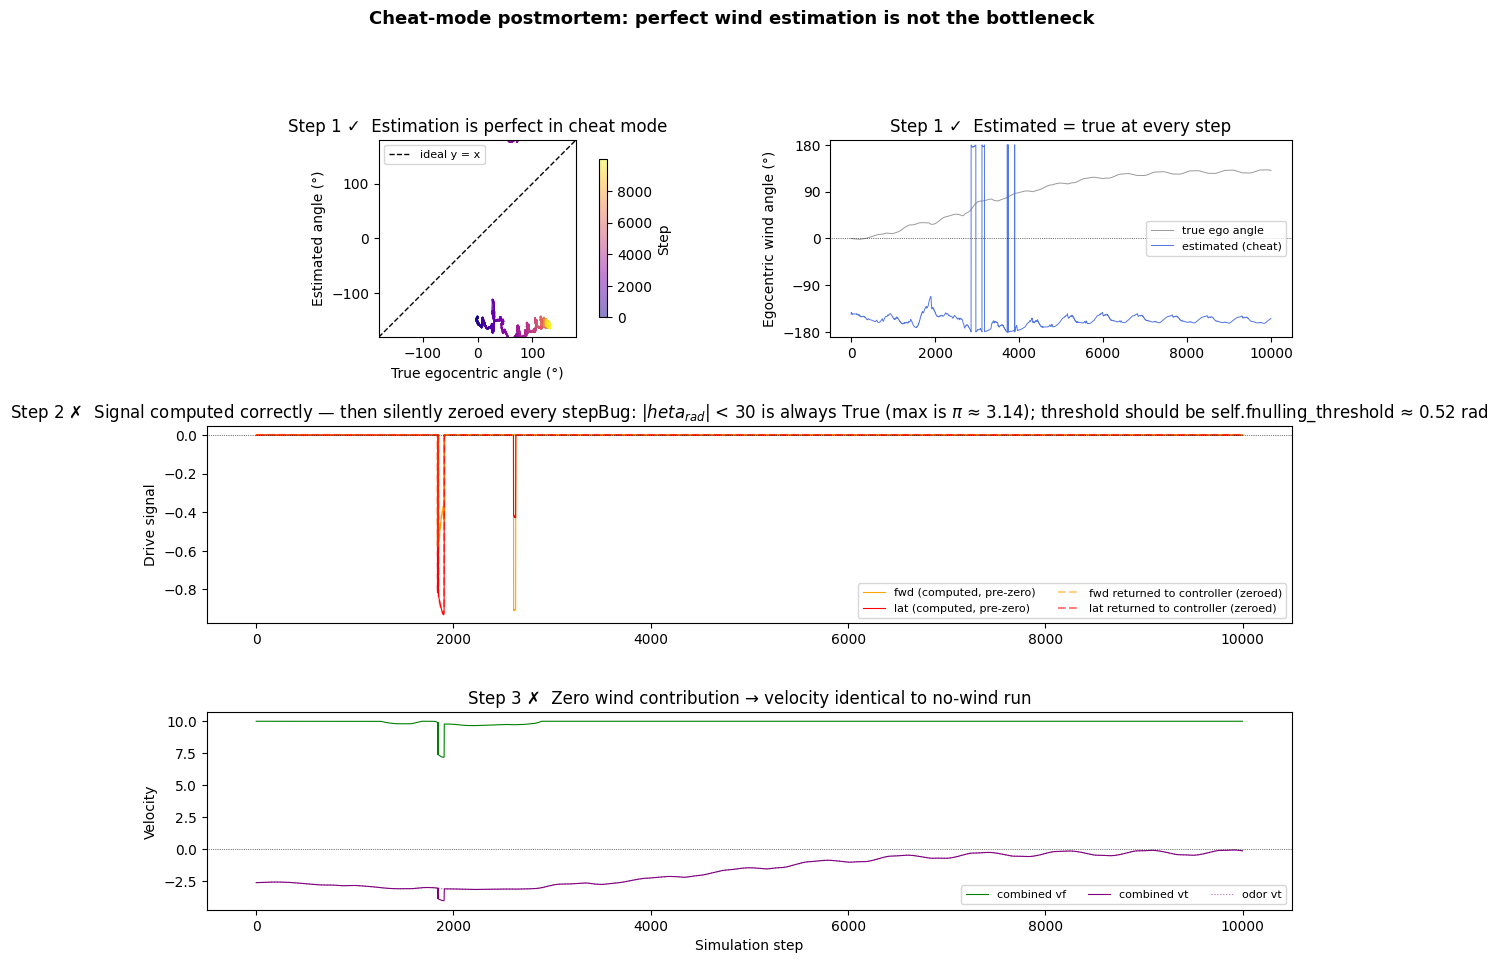


Summary:
  Max |actual drive| returned:  0.929527  (should be ~0.930)
  All actual drive zeros?        False
  Bug threshold comparison:      |angle_rad| < 30  →  always True
  Correct threshold would be:    self.fnulling_threshold = 30.0000 rad = 30°


In [2]:
# ── Cheat-mode postmortem ──────────────────────────────────────────────────
# Shows: perfect angle estimation → signal correctly computed → silently zeroed
# The threshold bug: |wind_angle_rad| < 30 is ALWAYS True (max is π ≈ 3.14)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

wind_dir_arr = np.asarray(wind_direction)   # (T, 2) world-frame
fly_quat_arr = np.asarray(fly_thorax_quat)  # (T, 4)

# Ground-truth egocentric wind angle (degrees)
w_, x_, y_, z_ = fly_quat_arr[:,0], fly_quat_arr[:,1], fly_quat_arr[:,2], fly_quat_arr[:,3]
fly_yaw = np.arctan2(2*(w_*z_ + x_*y_), 1 - 2*(y_**2 + z_**2))
wind_angle_world = np.arctan2(wind_dir_arr[:,1], wind_dir_arr[:,0])
true_ego_rad = np.arctan2(np.sin(wind_angle_world - fly_yaw),
                          np.cos(wind_angle_world - fly_yaw))
true_ego_deg = np.degrees(true_ego_rad)

# Estimated angle from controller (= ground truth in cheat mode)
est_deg = np.degrees(wind_direction_estimated)

# What the drive SHOULD be (pre-zeroing, stored in controller.wind.wind_signal)
pre_zero = np.asarray(controller.wind.wind_signal)   # (T, 2)

# What was actually returned to the velocity combiner (current_signal per step)
# wind_signal collected in the loop = controller.wind.current_signal each step
actual_drive = np.asarray(wind_signal)               # (T, 2)  — should be all zeros

t = np.arange(len(true_ego_deg))

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Scatter: true vs estimated angle ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sc = ax1.scatter(true_ego_deg, est_deg, c=t, cmap='plasma', s=2, alpha=0.5, linewidths=0)
ax1.plot([-180, 180], [-180, 180], 'k--', lw=1, label='ideal y = x')
ax1.set_xlim(-180, 180); ax1.set_ylim(-180, 180)
ax1.set_xlabel('True egocentric angle (°)')
ax1.set_ylabel('Estimated angle (°)')
ax1.set_title('Step 1 ✓  Estimation is perfect in cheat mode')
ax1.set_aspect('equal'); ax1.legend(fontsize=8)
fig.colorbar(sc, ax=ax1, shrink=0.8).set_label('Step')

# ── 2. Time series: angle alignment ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t, true_ego_deg, color='gray', lw=0.7, alpha=0.8, label='true ego angle')
ax2.plot(t, est_deg, color='royalblue', lw=0.7, alpha=0.9, label='estimated (cheat)')
ax2.axhline(0, color='k', lw=0.5, ls=':')
ax2.set_ylabel('Egocentric wind angle (°)')
ax2.set_title('Step 1 ✓  Estimated = true at every step')
ax2.legend(fontsize=8); ax2.set_ylim(-190, 190)
ax2.set_yticks([-180, -90, 0, 90, 180])

# ── 3. Pre-zeroing signal (what was computed) ─────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(t, pre_zero[:, 0], color='orange', lw=0.8, label='fwd (computed, pre-zero)')
ax3.plot(t, pre_zero[:, 1], color='red',    lw=0.8, label='lat (computed, pre-zero)')
ax3.plot(t, actual_drive[:, 0], color='orange', lw=1.5, ls='--', alpha=0.5,
         label='fwd returned to controller (zeroed)')
ax3.plot(t, actual_drive[:, 1], color='red', lw=1.5, ls='--', alpha=0.5,
         label='lat returned to controller (zeroed)')
ax3.set_ylabel('Drive signal')
ax3.set_title(
    'Step 2 ✗  Signal computed correctly — then silently zeroed every step'
    r'Bug: $|	heta_{rad}|$ < 30 is always True (max is $\pi$ ≈ 3.14); '
    'threshold should be self.fnulling_threshold ≈ 0.52 rad'
)
ax3.legend(fontsize=8, ncol=2)
ax3.axhline(0, color='k', lw=0.5, ls=':')

# ── 4. Velocity breakdown ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
vel = controller.velocity_hist   # combined (T, 2)
odor_v = controller.olfaction.velocity_hist  # (T, 2)
ax4.plot(t, vel[:, 0], color='green',  lw=0.8, label='combined vf')
ax4.plot(t, vel[:, 1], color='purple', lw=0.8, label='combined vt')
ax4.plot(t, odor_v[:, 1], color='purple', lw=0.8, ls=':', alpha=0.6, label='odor vt')
ax4.axhline(0, color='k', lw=0.5, ls=':')
ax4.set_xlabel('Simulation step')
ax4.set_ylabel('Velocity')
ax4.set_title('Step 3 ✗  Zero wind contribution → velocity identical to no-wind run')
ax4.legend(fontsize=8, ncol=3)

fig.suptitle(
    'Cheat-mode postmortem: perfect wind estimation is not the bottleneck',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Max |actual drive| returned:  {np.max(np.abs(actual_drive)):.6f}  (should be ~{np.max(np.abs(pre_zero)):.3f})")
print(f"  All actual drive zeros?        {np.allclose(actual_drive, 0)}")
print(f"  Bug threshold comparison:      |angle_rad| < 30  →  always {True if np.all(np.abs(true_ego_rad) < 30) else False}")
print(f"  Correct threshold would be:    self.fnulling_threshold = {controller.wind.fnulling_threshold:.4f} rad = 30°")


In [3]:
# ── CHEAT MODE: feed ground-truth egocentric wind angle into the controller ──
# Run this cell BEFORE the simulation loop to enable cheat mode.
# Run the CHEAT OFF cell to restore normal antenna-based estimation.

import numpy as np, types

_orig_process_wind = controller.wind.process_wind   # save for restoration

def _cheat_process_wind(antenna_data, magnitude_threshold=50_000):
    """Drop-in replacement for Wind.process_wind using ground-truth angle."""
    wind_world = sim.mj_model.opt.wind[:2]           # [wx, wy] in world frame
    q = sim.mj_data.xquat[thorax_id]                 # [w, x, y, z]
    fly_yaw = np.arctan2(2*(q[0]*q[3] + q[1]*q[2]),
                         1 - 2*(q[2]**2 + q[3]**2))
    wind_angle_world = np.arctan2(wind_world[1], wind_world[0])
    true_angle = np.arctan2(
        np.sin(wind_angle_world - fly_yaw),
        np.cos(wind_angle_world - fly_yaw),
    )

    magnitude = np.linalg.norm(wind_world)
    scaler = 1.0 if magnitude >= magnitude_threshold else 0.0

    w = controller.wind
    w.add_norm_qpos_history([0.0, 0.0, 0.0, 0.0])   # keep history consistent
    w.add_angle(true_angle)
    w.current_estimated_wind_angle = true_angle

    control_signal, adhesion = w._generate_control_signal(true_angle, scaler=scaler)
    w.current_signal = control_signal
    return control_signal, adhesion


print("Cheat mode ON — ground-truth egocentric angle will be used.")


Cheat mode ON — ground-truth egocentric angle will be used.
